Датасет: "Early Prediction of Sepsis from Clinical Data" Источник: https://physionet.org/content/challenge-2019/1.0.0/training/training_setB/#files-panel. 

Данный набор данных содержит временные ряды физиологических показателей пациентов в отделениях интенсивной терапии. Датасет был выбран, так как представляет собой реальную медицинскую задачу раннего выявления сепсиса и содержит сложные временные зависимости и большое количество пропусков.

Датасет содержит:

- 26512 пациентов
- 1014659 строк (временных наблюдений)
- 42 исходных признака (после feature engineering количество признаков увеличилось до 167)

В данных присутствует значительное количество пропусков, что характерно для медицинских временных рядов. Дубликаты отсутствуют. В данных присутствуют выбросы, что характерно для медицинских измерений. Такие значения могут отражать реальные критические состояния пациентов, поэтому они не удалялись.

Обработка пропусков: добавлены бинарные признаки, указывающие на наличие пропуска (is_missing), применено forward-fill (распространение последнего наблюдения) внутри каждого пациента, оставшиеся пропуски заполнены нулями, удалены дублирующие признаки (Unit1, Unit2), выполнена проверка и замена бесконечных значений

Были построены графики распределения основных физиологических показателей (например, частоты сердечных сокращений — HR). Анализ показал, что распределения имеют асимметрию и длинные хвосты, что характерно для медицинских данных и связано с наличием выбросов.

Также были построены графики зависимости признаков от целевой переменной (SepsisLabel). Наблюдается различие в распределениях некоторых показателей между классами, однако присутствует значительное перекрытие, что указывает на сложность задачи классификации и необходимость использования сложных моделей.

Анализ корреляционной матрицы показал наличие зависимостей между некоторыми физиологическими показателями. Однако не существует одного признака, который однозначно определяет наличие сепсиса, что подтверждает необходимость использования ансамбля признаков.


Все признаки были приведены к числовому виду. В результате итоговый датасет содержит только числовые признаки, пригодные для обучения моделей. Также признаки были нормализованы с помощью StandardScaler

Были созданы новые признаки:
- time_since_measured — время с последнего измерения показателя
- delta-признаки — изменение значения относительно предыдущего момента
- скользящие статистики (mean, min, max, std) за окно 6 часов
- индикаторы пропусков (is_missing)


Разбиение данных выполнено по пациентам (patient_id), что исключает попадание данных одного пациента одновременно в обучающую и тестовую выборки.
Для предотвращения утечки данных:
- использовался только forward-fill (без использования будущих значений)
- скользящие признаки рассчитывались только на основе прошлых значений (shift(1))
- сортировка данных выполнена по времени (ICULOS)

Таким образом, модель не имеет доступа к будущей информации.

In [34]:
!nbqa ruff preprocessing.ipynb

All checks passed!


In [32]:
import random
import os
import pandas as pd
import numpy as np
import joblib
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import seaborn as sns

import matplotlib.pyplot as plt


In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [3]:
def load_patient_file(filepath):
    df = pd.read_csv(filepath, sep='|')
    
    filename = os.path.basename(filepath)
    patient_id = filename.replace('.psv', '')
    
    df['patient_id'] = patient_id
    
    return df


def load_all_data(data_dir):
    all_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.psv')]
    
    dfs = []
    
    for file in tqdm(all_files):
        df = load_patient_file(file)
        dfs.append(df)
    
    full_df = pd.concat(dfs, ignore_index=True)
    return full_df


In [4]:
df_A = load_all_data("data/training_setA")
df_B = load_all_data("data/training_setB")
df = pd.concat([df_A, df_B], ignore_index=True)

print(df.shape)
df.head()

100%|██████████| 18889/18889 [00:17<00:00, 1089.43it/s]


(1014659, 42)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,65.55,1,NaN,NaN,-0.02,1,0,p000902
1,78.0,100.0,NaN,90.0,79.0,61.0,13.0,NaN,NaN,NaN,...,NaN,NaN,65.55,1,NaN,NaN,-0.02,2,0,p000902
2,80.0,100.0,NaN,82.0,72.0,56.0,19.0,NaN,NaN,NaN,...,NaN,NaN,65.55,1,NaN,NaN,-0.02,3,0,p000902
3,84.0,100.0,NaN,94.0,78.0,64.0,20.0,NaN,NaN,NaN,...,NaN,NaN,65.55,1,NaN,NaN,-0.02,4,0,p000902
4,83.0,99.0,36.11,94.0,87.0,66.0,16.0,NaN,NaN,NaN,...,NaN,NaN,65.55,1,NaN,NaN,-0.02,5,0,p000902


In [5]:
df = df.sort_values(['patient_id', 'ICULOS'])
df['patient_id'] = df['patient_id'].str[1:].astype(int)

In [6]:
df.head()

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
148653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,1
148654,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,1
148655,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,1
148656,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,1
148657,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,1


In [7]:
df.describe()

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
count,904421.000000,877416.000000,343925.000000,868696.000000,877923.000000,772146.000000,833157.000000,54443.000000,32962.000000,25113.000000,...,6168.000000,57619.000000,1.014659e+06,1.014659e+06,658225.000000,658225.000000,1.014659e+06,1.014659e+06,1.014659e+06,1.014659e+06
mean,84.413180,97.169805,36.956062,124.842842,83.975055,64.961995,18.699300,32.940699,-0.813563,24.042418,...,282.461576,194.558240,6.159205e+01,5.514335e-01,0.493924,0.506076,-5.691035e+01,2.689245e+01,1.601917e-02,7.865683e+04
std,17.501733,2.942357,0.768492,23.833447,16.652900,14.153666,4.935193,7.941350,4.383726,4.392052,...,148.351370,101.200832,1.648543e+01,4.973478e-01,0.499963,0.499963,1.627917e+02,2.951883e+01,1.255491e-01,4.824890e+04
min,20.000000,20.000000,20.900000,20.000000,20.000000,20.000000,1.000000,10.000000,-32.000000,0.000000,...,35.000000,1.000000,1.400000e+01,0.000000e+00,0.000000,0.000000,-5.366860e+03,1.000000e+00,0.000000e+00,1.000000e+00
25%,72.000000,96.000000,36.500000,107.000000,72.000000,55.000000,16.000000,28.000000,-3.000000,22.000000,...,182.000000,127.000000,5.100000e+01,0.000000e+00,0.000000,0.000000,-4.998000e+01,1.000000e+01,0.000000e+00,6.534000e+03
50%,83.000000,98.000000,36.940000,122.000000,82.000000,63.000000,18.000000,33.000000,0.000000,24.000000,...,248.000000,181.000000,6.321000e+01,1.000000e+00,0.000000,1.000000,-7.230000e+00,2.100000e+01,0.000000e+00,1.055930e+05
75%,95.500000,99.500000,37.440000,140.000000,94.000000,73.000000,21.000000,38.000000,1.000000,26.000000,...,345.000000,242.000000,7.326000e+01,1.000000e+00,1.000000,1.000000,-4.900000e-01,3.400000e+01,0.000000e+00,1.122350e+05
max,223.000000,100.000000,50.000000,300.000000,300.000000,300.000000,100.000000,100.000000,44.000000,52.000000,...,1760.000000,2322.000000,1.000000e+02,1.000000e+00,1.000000,1.000000,1.734000e+01,3.360000e+02,1.000000e+00,1.188890e+05


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1014659 entries, 148653 to 563407
Data columns (total 42 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   HR                904421 non-null   float64
 1   O2Sat             877416 non-null   float64
 2   Temp              343925 non-null   float64
 3   SBP               868696 non-null   float64
 4   MAP               877923 non-null   float64
 5   DBP               772146 non-null   float64
 6   Resp              833157 non-null   float64
 7   EtCO2             54443 non-null    float64
 8   BaseExcess        32962 non-null    float64
 9   HCO3              25113 non-null    float64
 10  FiO2              57916 non-null    float64
 11  pH                50309 non-null    float64
 12  PaCO2             42169 non-null    float64
 13  SaO2              28428 non-null    float64
 14  AST               16941 non-null    float64
 15  BUN               63780 non-null    float64
 16  A

In [9]:
df.isna().sum()

HR                   110238
O2Sat                137243
Temp                 670734
SBP                  145963
MAP                  136736
DBP                  242513
Resp                 181502
EtCO2                960216
BaseExcess           981697
HCO3                 989546
FiO2                 956743
pH                   964350
PaCO2                972490
SaO2                 986231
AST                  997718
BUN                  950879
Alkalinephos         997796
Calcium              951259
Chloride             985648
Creatinine           955458
Bilirubin_direct    1012503
Glucose              819286
Lactate              990961
Magnesium            957326
Phosphate            978851
Potassium            926997
Bilirubin_total      998436
TroponinI           1001193
Hct                  937432
Hgb                  946011
PTT                  993479
WBC                  954579
Fibrinogen          1008491
Platelets            957040
Age                       0
Gender              

In [10]:
df.duplicated().sum()

0

In [11]:
for col in df.select_dtypes(include=[np.number]).columns:
    if col not in ['patient_id', 'SepsisLabel', 'ICULOS']:
        print(f"{col:20} | min = {df[col].min():8.2f} | max = {df[col].max():8.2f}")

HR                   | min =    20.00 | max =   223.00
O2Sat                | min =    20.00 | max =   100.00
Temp                 | min =    20.90 | max =    50.00
SBP                  | min =    20.00 | max =   300.00
MAP                  | min =    20.00 | max =   300.00
DBP                  | min =    20.00 | max =   300.00
Resp                 | min =     1.00 | max =   100.00
EtCO2                | min =    10.00 | max =   100.00
BaseExcess           | min =   -32.00 | max =    44.00
HCO3                 | min =     0.00 | max =    52.00
FiO2                 | min =   -50.00 | max =  4000.00
pH                   | min =     6.62 | max =     7.78
PaCO2                | min =    10.00 | max =   100.00
SaO2                 | min =    23.00 | max =   100.00
AST                  | min =     5.00 | max =  9961.00
BUN                  | min =     1.00 | max =   268.00
Alkalinephos         | min =     7.00 | max =  2528.00
Calcium              | min =     1.00 | max =    27.90
Chloride  

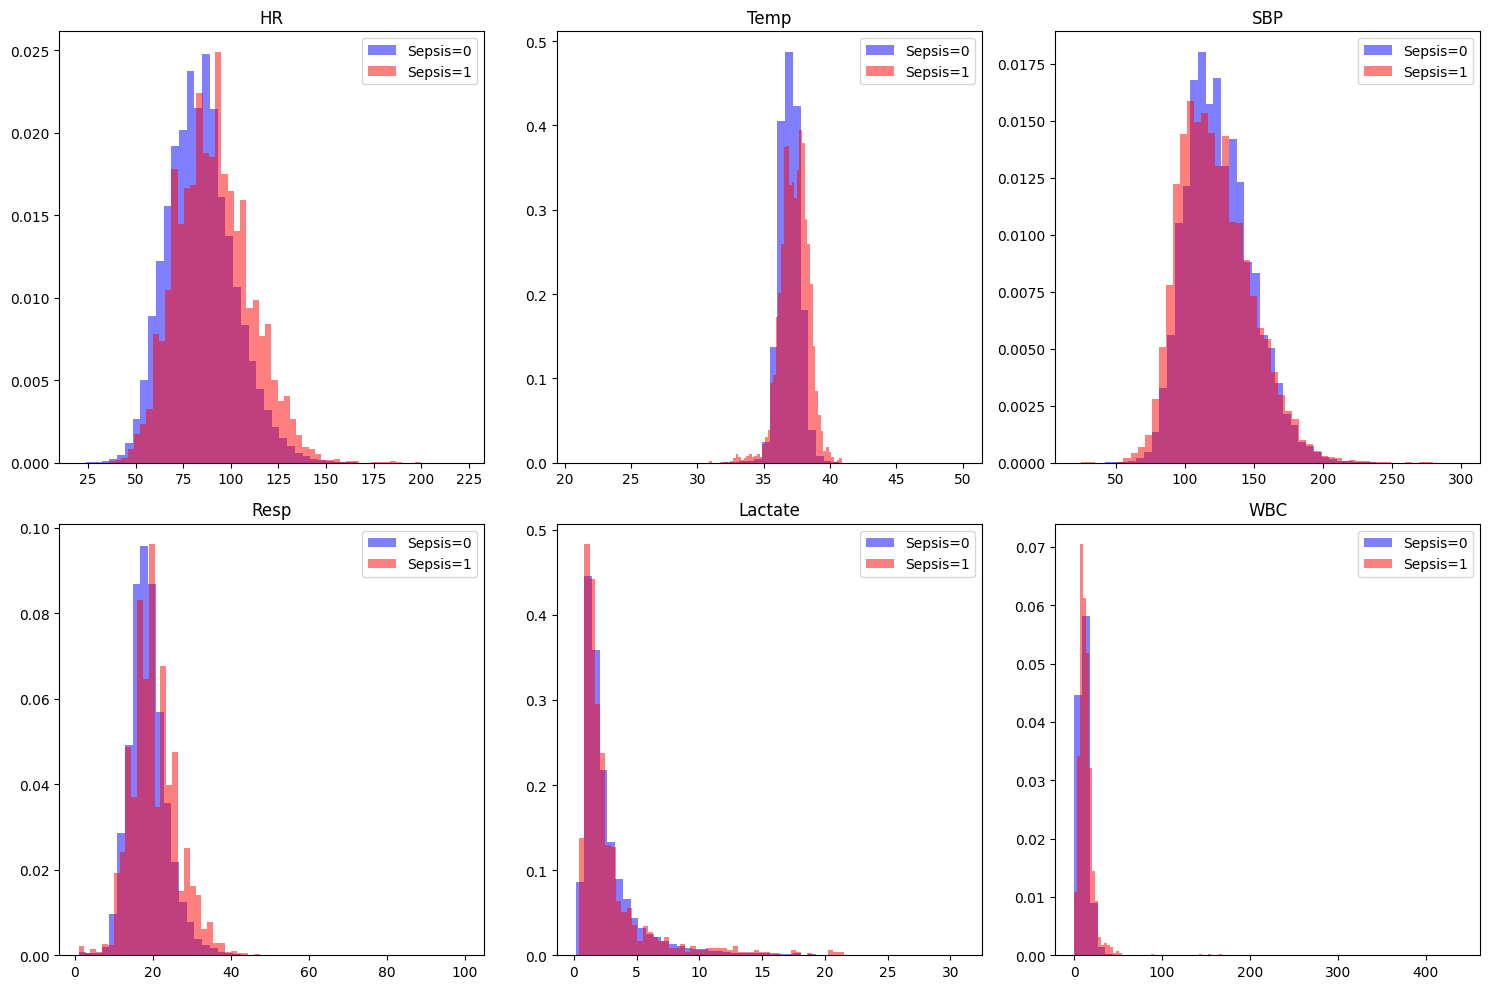

In [12]:
key_features = ['HR', 'Temp', 'SBP', 'Resp', 'Lactate', 'WBC']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    if feat in df.columns:
        for label, color in [(0, 'blue'), (1, 'red')]:
            subset = df[df['SepsisLabel'] == label][feat].dropna()
            axes[i].hist(subset, bins=50, alpha=0.5, label=f'Sepsis={label}', color=color, density=True)
        axes[i].set_title(feat)
        axes[i].legend()
plt.tight_layout()
plt.show()

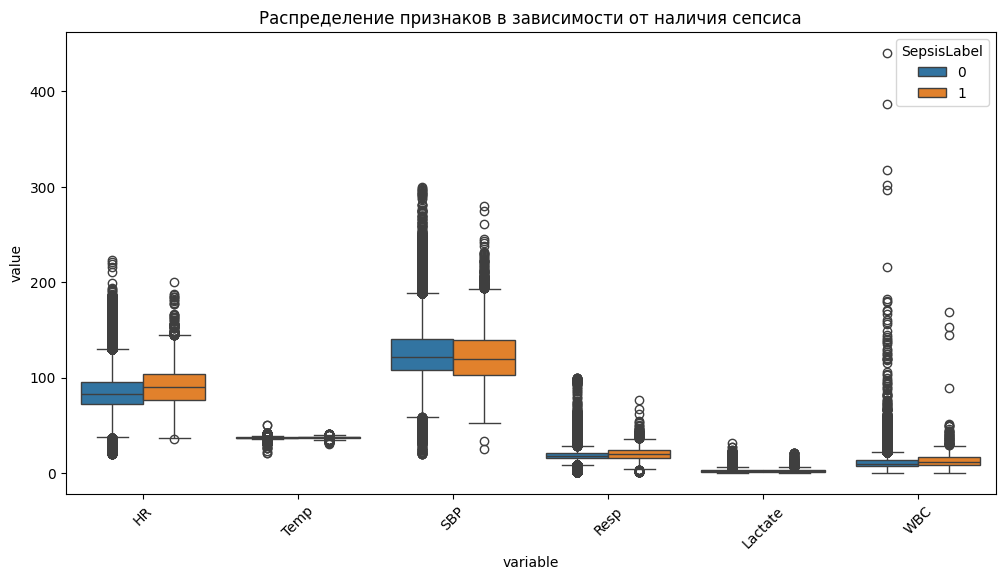

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.melt(id_vars='SepsisLabel', value_vars=key_features), 
            x='variable', y='value', hue='SepsisLabel')
plt.xticks(rotation=45)
plt.title('Распределение признаков в зависимости от наличия сепсиса')
plt.show()

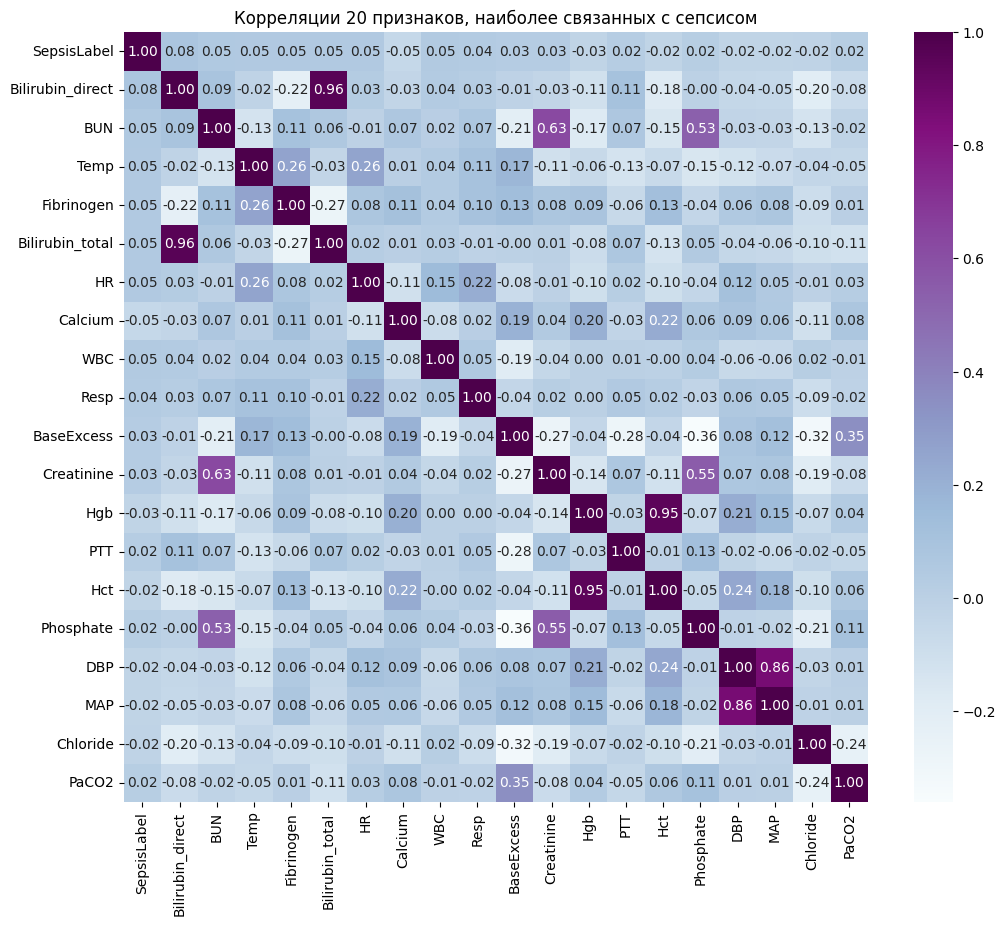

In [14]:
original_features = [c for c in df.columns if c not in ['patient_id', 'ICULOS']]
top_corr = df[original_features].corrwith(df['SepsisLabel']).abs().sort_values(ascending=False).head(20).index
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_corr].corr(), annot=True, cmap='BuPu', fmt='.2f')
plt.title('Корреляции 20 признаков, наиболее связанных с сепсисом')
plt.show()

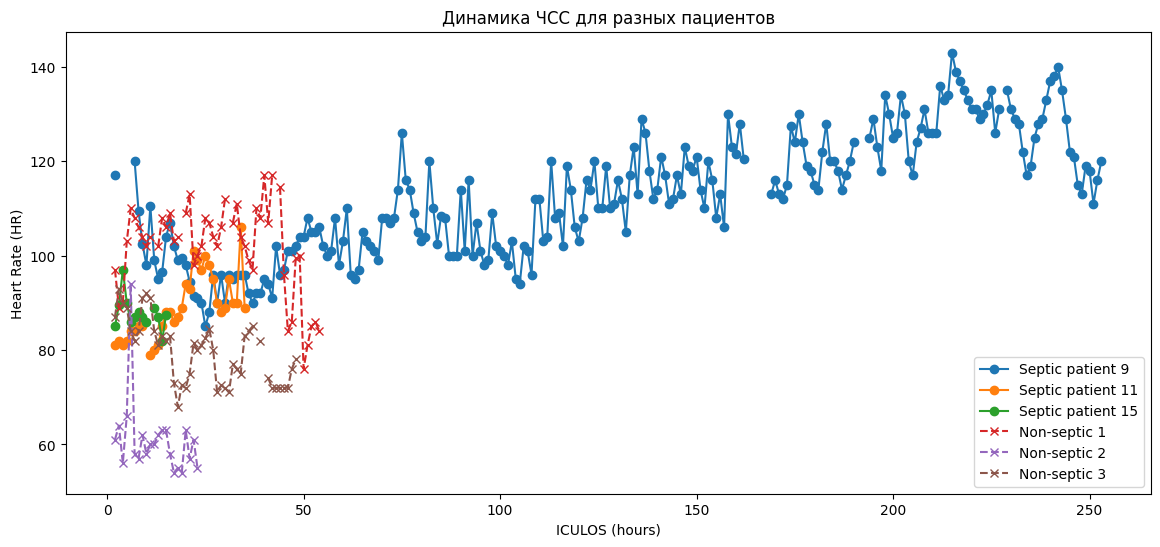

In [15]:
septic_patients = df[df['SepsisLabel']==1]['patient_id'].unique()[:3]
non_septic = df[df['SepsisLabel']==0]['patient_id'].unique()[:3]

plt.figure(figsize=(14, 6))
for pid in septic_patients:
    sub = df[df['patient_id']==pid].sort_values('ICULOS')
    plt.plot(sub['ICULOS'], sub['HR'], marker='o', label=f'Septic patient {pid}')
for pid in non_septic:
    sub = df[df['patient_id']==pid].sort_values('ICULOS')
    plt.plot(sub['ICULOS'], sub['HR'], marker='x', linestyle='--', label=f'Non-septic {pid}')
plt.xlabel('ICULOS (hours)')
plt.ylabel('Heart Rate (HR)')
plt.legend()
plt.title('Динамика ЧСС для разных пациентов')
plt.show()

In [16]:
patient_labels = df.groupby('patient_id')['SepsisLabel'].max()

patients = patient_labels.index
labels = patient_labels.values

print("Patients:", len(patients))
print("Sepsis rate:", labels.mean())

Patients: 26512
Sepsis rate: 0.06464996982498492


In [17]:
train_p, test_p = train_test_split(
    patients,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
train_labels = patient_labels.loc[train_p]

train_p, val_p = train_test_split(
    train_p,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

In [18]:
train_df = df[df['patient_id'].isin(train_p)].copy()
val_df   = df[df['patient_id'].isin(val_p)].copy()
test_df  = df[df['patient_id'].isin(test_p)].copy()


print("Train sepsis rate:", train_df['SepsisLabel'].mean())
print("Val sepsis rate:", val_df['SepsisLabel'].mean())
print("Test sepsis rate:", test_df['SepsisLabel'].mean())


print("Train patients:", train_df['patient_id'].nunique())
print("Val patients:", val_df['patient_id'].nunique())
print("Test patients:", test_df['patient_id'].nunique())

Train sepsis rate: 0.016067562517565453
Val sepsis rate: 0.015865173473869128
Test sepsis rate: 0.015989209252868754
Train patients: 16967
Val patients: 4242
Test patients: 5303


In [19]:
def add_time_since_measured(df, feature_cols):
    df = df.copy()

    for col in feature_cols:
        mask = df[col].notna()

        t = df.groupby('patient_id').cumcount()

        last_measured = (
            t.where(mask)
            .groupby(df['patient_id'])
            .ffill()
        )

        df[f'{col}_time_since_measured'] = (t - last_measured).fillna(-1)

    return df

In [20]:
def add_clinical_scores(df):
    df = df.copy()
    # SIRS
    sirs_temp = ((df['Temp'] > 38) | (df['Temp'] < 36)).astype(int)
    sirs_hr = (df['HR'] > 90).astype(int)
    sirs_rr_high = (df['Resp'] > 20)
    sirs_pco2_low = (df['PaCO2'] < 32) if 'PaCO2' in df.columns else False
    sirs_resp = (sirs_rr_high | sirs_pco2_low).astype(int)
    sirs_wbc_high = (df['WBC'] > 12)
    sirs_wbc_low = (df['WBC'] < 4)
    sirs_wbc = (sirs_wbc_high | sirs_wbc_low).astype(int)
    df['SIRS_temp'] = sirs_temp
    df['SIRS_hr'] = sirs_hr
    df['SIRS_resp'] = sirs_resp
    df['SIRS_wbc'] = sirs_wbc
    df['SIRS_sum'] = sirs_temp + sirs_hr + sirs_resp + sirs_wbc

    # qSOFA2 (без оценки сознания)
    df['qSOFA2_resp'] = (df['Resp'] >= 22).astype(int)
    df['qSOFA2_sbp'] = (df['SBP'] <= 100).astype(int)
    df['qSOFA2_sum'] = df['qSOFA2_resp'] + df['qSOFA2_sbp']

    return df

In [21]:
def prepare_data(df, window=6):
    df = df.copy()
    df['Unit'] = np.where(
        df['Unit1'] == 1, 'MICU',
        np.where(df['Unit2'] == 1, 'SICU', 'UNKNOWN')
    )
    df = pd.get_dummies(df, columns=['Unit'])
    df = df.drop(columns=['Unit1', 'Unit2'])

    df = df.sort_values(['patient_id', 'ICULOS'])

    exclude = ['patient_id', 'SepsisLabel', 'ICULOS', 'Unit1', 'Unit2']
    feature_cols = [c for c in df.columns if c not in exclude]

    base_features = [
        'HR','O2Sat','Temp','SBP','MAP','DBP','Resp',
        'Glucose','Lactate','Creatinine','WBC','Platelets','Hgb','Hct'
    ]
    base_features = [c for c in base_features if c in df.columns]

    df = add_time_since_measured(df, base_features)

    for col in feature_cols:
        df[f'{col}_is_missing'] = df[col].isna().astype(int)

    fill_cols = [c for c in df.columns if c != 'patient_id']
    df[fill_cols] = df.groupby('patient_id')[fill_cols].ffill()
    df = df.reset_index(drop=True)

    medians = df[base_features].median()
    df[base_features] = df[base_features].fillna(medians)

    df = add_clinical_scores(df)

    for col in base_features:
        g = df.groupby('patient_id')[col]
        shifted = g.shift(1)
        df[f'{col}_mean_{window}h'] = shifted.rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
        df[f'{col}_max_{window}h']  = shifted.rolling(window, min_periods=1).max().reset_index(level=0, drop=True)
        df[f'{col}_min_{window}h']  = shifted.rolling(window, min_periods=1).min().reset_index(level=0, drop=True)
        df[f'{col}_std_{window}h']  = shifted.rolling(window, min_periods=1).std().reset_index(level=0, drop=True)

    for col in base_features:
        df[f'{col}_diff'] = (
            df.groupby('patient_id')[col]
            .diff()
            .fillna(0)
        )

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)

    print("Final shape:", df.shape)
    return df

In [22]:
train_df = prepare_data(train_df)
val_df   = prepare_data(val_df)
test_df  = prepare_data(test_df)

Final shape: (647578, 175)
Final shape: (163944, 175)
Final shape: (203137, 175)


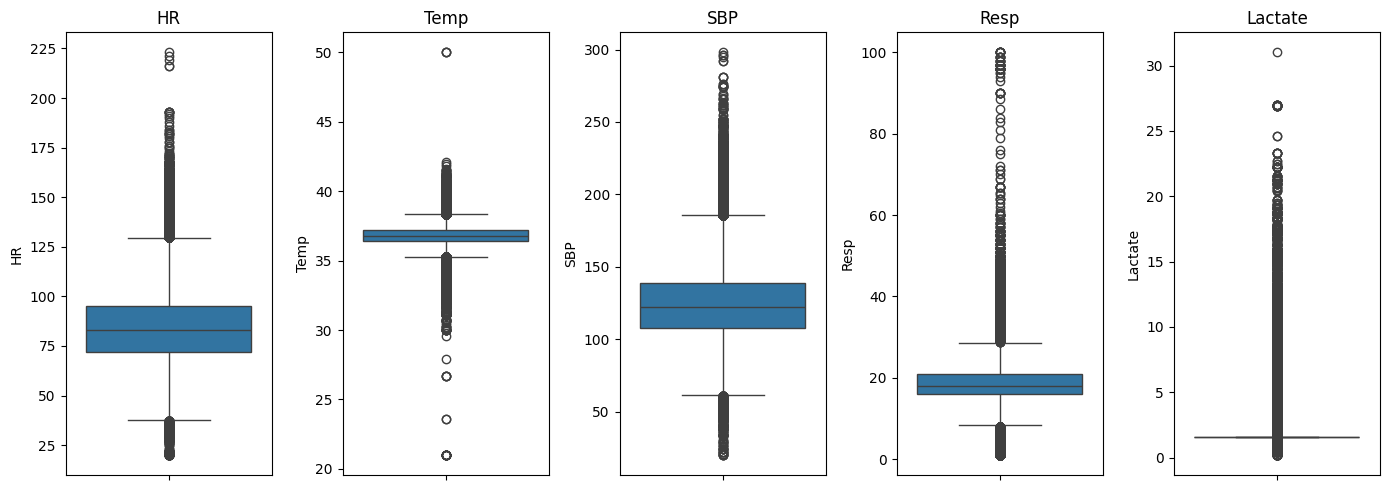

In [23]:
plt.figure(figsize=(14, 5))
plot_features = ['HR', 'Temp', 'SBP', 'Resp', 'Lactate']
for i, feat in enumerate(plot_features):
    if feat in train_df.columns:
        plt.subplot(1, len(plot_features), i+1)
        sns.boxplot(y=train_df[feat])
        plt.title(feat)
plt.tight_layout()
plt.show()

In [24]:
TARGET = 'SepsisLabel'

drop_cols = ['patient_id', 'ICULOS', 'SepsisLabel']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[TARGET]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[TARGET]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[TARGET]

In [25]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(647578, 172) (647578,)
(163944, 172) (163944,)


In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [28]:
np.save('data/X_train_scaled.npy', X_train_scaled)
np.save('data/X_val_scaled.npy', X_val_scaled)
np.save('data/X_test_scaled.npy', X_test_scaled)

np.save('data/y_train.npy', y_train)
np.save('data/y_val.npy', y_val)
np.save('data/y_test.npy', y_test)

joblib.dump(scaler, 'data/scaler.pkl')

print("Данные успешно сохранены в папку data.")

Данные успешно сохранены в папку data.
